# Orientation: output semantics and diagnostics

Monte Carlo methods can return **IID draws**, **weighted particles**, **correlated states**, or **approximate draws**. Those are not interchangeable output types. This notebook develops a compact diagnostic vocabulary before later notebooks introduce particular algorithms.

We will check three predictions:

1. IID root-mean-square error decreases like $N^{-1/2}$.
2. Concentrated importance weights reduce the weight effective sample size.
3. Positive serial correlation inflates variance; treating a chain as IID is overconfident.

See the [benchmark semantics](../benchmarking.md) and [API reference](../api.md) for the repository-wide contracts.

**Output labels used throughout the tutorials**

| Label | What is exact? | Typical uncertainty summary |
|---|---|---|
| Exact IID | Every retained draw has the target law and draws are independent | IID standard error |
| Corrected Markov | The transition kernel has the target invariant law | IAT / Markov-chain ESS |
| Weighted | Expectations use normalized or unnormalized weights | weight diagnostics plus estimator-specific error |
| Approximate | Discretization, adaptation, or optimization changes the target | bias diagnostics and sensitivity studies |

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import sampler_lab
from sampler_lab import spawn_rngs

warnings.filterwarnings("error")
warnings.filterwarnings("ignore", category=PendingDeprecationWarning, module="ipykernel")
QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
MODE = "quick" if QUICK_MODE else "publication"
plt.rcParams.update({"figure.dpi": 105, "figure.figsize": (7.2, 4.3)})
FIGURE_COUNT = 0
print(f"sampler-lab {sampler_lab.__version__} | execution mode: {MODE}")

from sampler_lab.diagnostics import (
    empirical_autocorrelations,
    empirical_effective_sample_size,
    empirical_integrated_autocorrelation_time,
    weight_diagnostics,
)
from sampler_lab.estimators import iid_estimate
from sampler_lab.exact import box_muller

sampler-lab 0.12.0 | execution mode: publication


## IID error scaling

For $Z\sim N(0,1)$, estimate $\mathbb E[Z^2]=1$. Since $\operatorname{Var}(Z^2)=2$, the estimator standard deviation is $\sqrt{2/N}$. On log-log axes the repeated-run RMSE should therefore have slope $-1/2$.

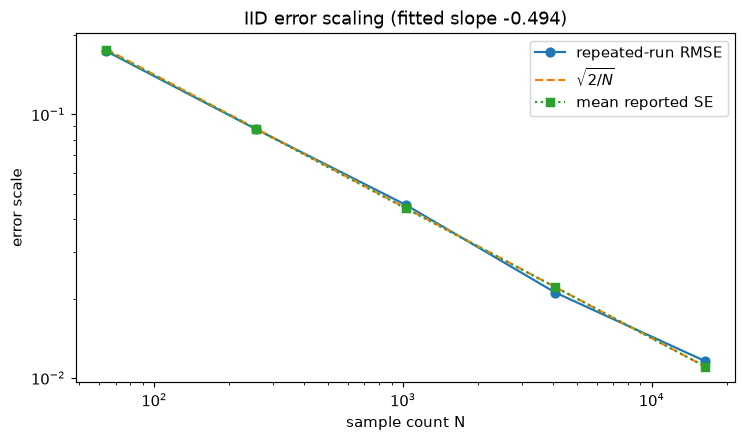

In [2]:
seed_sizes = [64, 256, 1024, 4096] if QUICK_MODE else [64, 256, 1024, 4096, 16384]
replicates = 80 if QUICK_MODE else 300
streams = iter(spawn_rngs(202601, len(seed_sizes) * replicates))
rmse = []
reported_se = []
for n in seed_sizes:
    estimates = []
    ses = []
    for _ in range(replicates):
        result = iid_estimate(box_muller(next(streams), n), observable=lambda z: z**2)
        estimates.append(result.value)
        ses.append(result.standard_error)
    rmse.append(float(np.sqrt(np.mean((np.asarray(estimates) - 1.0) ** 2))))
    reported_se.append(float(np.mean(ses)))
rmse_slope = float(np.polyfit(np.log(seed_sizes), np.log(rmse), 1)[0])
fig, ax = plt.subplots()
ax.loglog(seed_sizes, rmse, "o-", label="repeated-run RMSE")
ax.loglog(seed_sizes, np.sqrt(2 / np.asarray(seed_sizes)), "--", label=r"$\sqrt{2/N}$")
ax.loglog(seed_sizes, reported_se, "s:", label="mean reported SE")
ax.set(
    xlabel="sample count N",
    ylabel="error scale",
    title=f"IID error scaling (fitted slope {rmse_slope:.3f})",
)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1

The empirical RMSE and the reported IID standard error track the analytical $N^{-1/2}$ reference. A single estimate can be lucky or unlucky; repeated-run distributions are the more reliable calibration object.

## Weighted output and effective sample size

For normalized weights $\omega_i$, the package reports

$$\operatorname{ESS}_w=\frac{1}{\sum_i\omega_i^2}.$$

This is a concentration diagnostic, not a guarantee about every observable. We create increasingly tilted log weights on a fixed cloud. The sorted-weight curve should become steeper and ESS should fall.

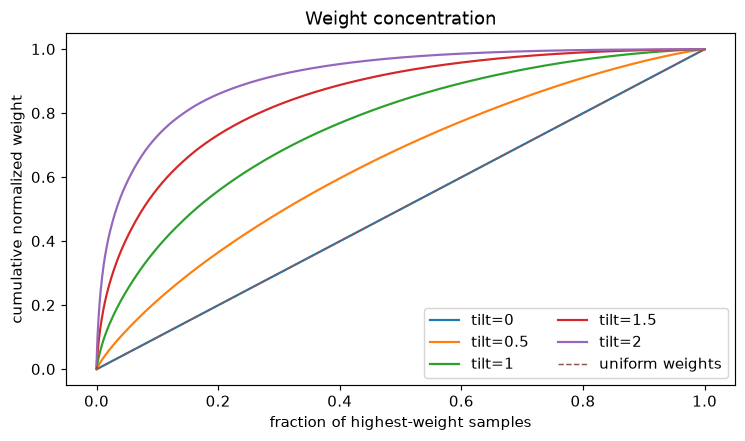

{np.float64(0.0): np.float64(1.0), np.float64(0.5): np.float64(0.785), np.float64(1.0): np.float64(0.408), np.float64(1.5): np.float64(0.166), np.float64(2.0): np.float64(0.064)}


In [3]:
weight_rng = spawn_rngs(202602, 1)[0]
base = weight_rng.normal(size=3000 if QUICK_MODE else 12000)
tilts = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
ess_fractions = []
fig, ax = plt.subplots()
for tilt in tilts:
    log_weights = tilt * base
    diagnostics = weight_diagnostics(log_weights)
    ess_fractions.append(diagnostics.ess_fraction)
    weights = np.exp(log_weights - np.max(log_weights))
    weights /= np.sum(weights)
    cumulative = np.cumsum(np.sort(weights)[::-1])
    ax.plot(np.arange(1, cumulative.size + 1) / cumulative.size, cumulative, label=f"tilt={tilt:g}")
ax.plot([0, 1], [0, 1], "--", linewidth=1, label="uniform weights")
ax.set(
    xlabel="fraction of highest-weight samples",
    ylabel="cumulative normalized weight",
    title="Weight concentration",
)
ax.legend(ncol=2)
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1
print(dict(zip(tilts, np.round(ess_fractions, 3), strict=True)))

The curve for uniform weights lies on the diagonal. Increasing tilt lets a smaller fraction of samples carry most of the mass. The ESS fraction falls monotonically, exactly as the concentration identity predicts.

## Correlated output: trace, ACF, IAT, and ESS

For a stationary AR(1) process $X_t=\rho X_{t-1}+\sqrt{1-\rho^2}\,\varepsilon_t$, the exact integrated autocorrelation time for the mean is

$$\tau=1+2\sum_{k\ge1}\rho^k=\frac{1+\rho}{1-\rho}.$$

At $\rho=0.8$, the theoretical value is $9$: nine correlated states contain roughly the information in one IID draw.

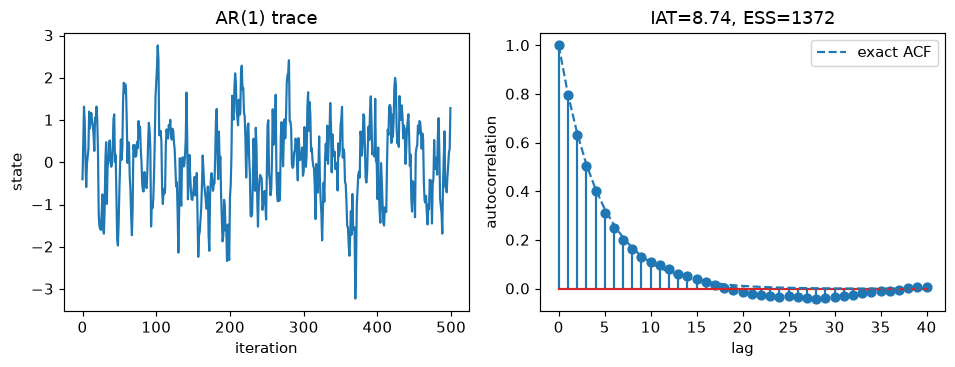

naive IID SE=0.0092; IAT-adjusted SE=0.0272; exact IAT=9.0


In [4]:
rho = 0.8
n_chain = 2500 if QUICK_MODE else 12000
chain_rng = spawn_rngs(202603, 1)[0]
chain = np.empty(n_chain)
chain[0] = chain_rng.normal()
noise = chain_rng.normal(size=n_chain - 1)
for index in range(1, n_chain):
    chain[index] = rho * chain[index - 1] + np.sqrt(1 - rho**2) * noise[index - 1]
acf = empirical_autocorrelations(chain, max_lag=40)
iat = empirical_integrated_autocorrelation_time(chain, max_lag=min(1000, n_chain - 1))
ess = empirical_effective_sample_size(chain, max_lag=min(1000, n_chain - 1))
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.6))
axes[0].plot(chain[:500])
axes[0].set(xlabel="iteration", ylabel="state", title="AR(1) trace")
axes[1].stem(np.arange(acf.size), acf)
axes[1].plot(np.arange(acf.size), rho ** np.arange(acf.size), "--", label="exact ACF")
axes[1].set(xlabel="lag", ylabel="autocorrelation", title=f"IAT={iat:.2f}, ESS={ess:.0f}")
axes[1].legend()
fig.tight_layout()
plt.show()
plt.close(fig)
FIGURE_COUNT += 1
naive_se = float(np.std(chain, ddof=1) / np.sqrt(n_chain))
corrected_se = naive_se * np.sqrt(iat)
print(
    f"naive IID SE={naive_se:.4f}; IAT-adjusted SE={corrected_se:.4f}; "
    f"exact IAT={(1 + rho) / (1 - rho):.1f}"
)

The trace is visibly persistent, and the empirical ACF follows the geometric prediction. Ignoring correlation understates the standard error by roughly $\sqrt{	au}$. Retaining repeated or rejected states is therefore essential: deleting them manufactures fake efficiency.

## When to use which diagnostic

- **IID samples:** moment checks, repeated-run calibration, empirical CDFs, and ordinary standard errors.
- **Weighted samples:** log-weight stability, ESS, maximum weight, entropy, and estimator-specific variance.
- **Markov chains:** traces, ACFs, IAT/ESS, multiple starts, and target-specific mode diagnostics.
- **Approximate methods:** all of the above plus step-size, discretization, or optimization sensitivity.

Further experiments: vary $ho$; replace Gaussian observations by a heavy-tailed law; or construct two weight vectors with equal ESS but different effects on a chosen observable.

In [5]:
assert -0.7 < rmse_slope < -0.3
assert np.all(np.diff(ess_fractions) <= 0.0)
assert iat > 4.0
assert corrected_se > 1.8 * naive_se
EXPECTED_FIGURES = 3
assert FIGURE_COUNT == EXPECTED_FIGURES
print(f"Notebook checks passed; expected figures: {EXPECTED_FIGURES}")

Notebook checks passed; expected figures: 3
